# SS3 Part B: Applying the Concentration Risk Model to Real Client Data

This notebook applies the model selected in SS2 (XGBoost, see `experiments/results/Comparison.MD`) to STADIOEquities' real client data extract, received for SS3. The SS2 pipeline was built and validated on a public proxy dataset (SEC Form 13F institutional holdings); this notebook adapts that validated methodology to the client's own portfolio, transaction, and complaint data.

**Sections:**
1. Dataset Loading
2. Dataset Preprocessing
3. Model Training
4. Model Validation
5. Results Visualisation

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc




## 1. Dataset Loading

In [2]:
DATA_DIR = "../data/raw/client_extract"

client_info = pd.read_csv(f"{DATA_DIR}/table1_client_account_information.csv", dtype={"client_id": str})
holdings = pd.read_csv(f"{DATA_DIR}/table2_portfolio_holdings.csv", dtype={"client_id": str})
transactions = pd.read_csv(f"{DATA_DIR}/table3_transaction_history.csv", dtype={"client_id": str})
complaints = pd.read_csv(f"{DATA_DIR}/table4_support_complaint_history.csv", dtype={"client_id": str})

print("table1_client_account_information:", client_info.shape)
print("table2_portfolio_holdings:        ", holdings.shape)
print("table3_transaction_history:       ", transactions.shape)
print("table4_support_complaint_history: ", complaints.shape)

table1_client_account_information: (419, 7)
table2_portfolio_holdings:         (45660, 9)
table3_transaction_history:        (4175, 10)
table4_support_complaint_history:  (130, 7)


In [3]:
for name, df in [
    ("table1_client_account_information", client_info), ("table2_portfolio_holdings", holdings), ("table3_transaction_history", transactions), ("table4_support_complaint_history", complaints),]:
    
    print(f"\n{name}")
    print(df.dtypes)
    print("\nnulls:\n", df.isna().sum()[df.isna().sum() > 0])


table1_client_account_information
client_id                     str
client_age                float64
account_open_date             str
client_province               str
stated_risk_appetite          str
stated_investment_goal        str
account_status                str
dtype: object

nulls:
 client_age                 3
stated_investment_goal    14
dtype: int64

table2_portfolio_holdings
client_id                          str
snapshot_date                      str
instrument_ticker                  str
exchange                           str
instrument_name                    str
sector                             str
quantity_held                  float64
market_value_of_holding_zar    float64
total_portfolio_value_zar      float64
dtype: object

nulls:
 Series([], dtype: int64)

table3_transaction_history
client_id                    str
transaction_id               str
transaction_date             str
transaction_type             str
order_type                   str
instrument_tic

### Instance counts

| Table | Rows | Grain |
|---|---|---|
| `table1_client_account_information` | 419 | one row per client |
| `table2_portfolio_holdings` | 45,660 | one row per client-instrument-month (12 monthly snapshots to 31 Aug 2026) |
| `table3_transaction_history` | 4,175 | one row per executed buy/sell |
| `table4_support_complaint_history` | 130 | one row per complaint/support ticket |

Missing values confirm the data quality notes in the extract's README: `client_age` (3 missing) and `stated_investment_goal` (14 missing) in `table1`; `complaint_category` (85 missing, i.e. only 45/130 = 34.6% categorised) and `related_instrument_ticker` (84 missing) in `table4`. `table2` and `table3` show no null values in this pass, though the README notes casing, whitespace, duplicate-record, and date-format issues that do not surface as nulls and are investigated in Dataset Preprocessing below.

### Classes and class imbalance

This dataset does not arrive with a pre-built label. The outcome of interest is whether a client's **observed portfolio concentration contradicts their stated risk appetite** (e.g. a client who states a low risk appetite but holds a highly concentrated position), which the data provider has indicated is over-represented among suitability complaints in `table4_support_complaint_history`.

The label is a binary classification target (flagged / not flagged), constructed in Dataset Preprocessing below from `hhi` (75th-percentile threshold, 0.250) and `stated_risk_appetite`, and validated against real suitability complaints in `table4_support_complaint_history`.

**Class balance: 401 negative (95.93%) / 17 positive (4.07%)**, out of 418 clients. This figure is computed from the label constructed in section 2.4 below; it is stated here because class imbalance is part of what Dataset Loading is expected to report, and preprocessing (including the label construction and its validation against real complaint data) follows in the next section. This is a substantial imbalance, consistent with concentration-driven risk being a minority outcome among this client base, and is handled in Model Training below via class weighting.

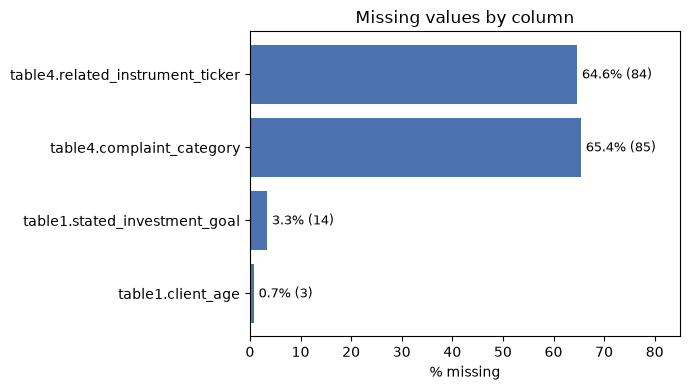

In [4]:
missing_summary = pd.DataFrame([
    {"table": "table1", "column": "client_age", "missing": 3, "total": 419},
    {"table": "table1", "column": "stated_investment_goal", "missing": 14, "total": 419},
    {"table": "table4", "column": "complaint_category", "missing": 85, "total": 130},
    {"table": "table4", "column": "related_instrument_ticker", "missing": 84, "total": 130},
])
missing_summary["pct_missing"] = missing_summary["missing"] / missing_summary["total"] * 100
missing_summary["label"] = missing_summary["table"] + "." + missing_summary["column"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(missing_summary["label"], missing_summary["pct_missing"], color="#4C72B0")
for bar, pct, n in zip(bars, missing_summary["pct_missing"], missing_summary["missing"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}% ({n})", va="center", fontsize=9)

ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
ax.set_xlim(0, max(missing_summary["pct_missing"]) * 1.3)
fig.tight_layout()
plt.savefig("missing_values.png", dpi=150, bbox_inches="tight")
plt.show()